## Imports + load configs + import the actual simulation grid (Chebyshev Re/α)

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 120

In [2]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- Make sure local package imports work when notebook is in glider_optimization/glider_optimization/utils ---
HERE = Path.cwd().resolve()
PKG_DIR = HERE.parent  # .../glider_optimization/glider_optimization
PROJ_DIR = PKG_DIR.parent  # .../glider_optimization
CONF_DIR = PROJ_DIR / "conf"

import sys
if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

from glider_optimization.config import load_config
from glider_optimization.blocks.neuralFoilSampling3D import NeuralFoilSampling3D

# --- Load the same configs your runs use ---
# baseline config (test_simple.yaml) and optimised config (test.yaml) are present in your zip
cfg_base = load_config(CONF_DIR / "test_simple.yaml")
cfg_opt  = load_config(CONF_DIR / "test.yaml")

# --- Instantiate the actual block to get the exact alpha/Re grid used in simulation ---
nf3d = NeuralFoilSampling3D(cfg_opt)  # grid comes from nfConfig; geometry doesn't affect grid

alpha_grid = nf3d.alpha_batch.detach().cpu().numpy()  # length n_samples
Re_grid    = nf3d.Re_batch.detach().cpu().numpy()

# Also useful: unique 1D lists (dropdown uses these)
Re_1d = np.unique(Re_grid)
alpha_1d = np.unique(alpha_grid)

print("Loaded simulation grid:")
print(" n_samples:", len(alpha_grid))
print(" alpha_1d:", alpha_1d.shape, "Re_1d:", Re_1d.shape)
print(" alpha range:", float(alpha_1d.min()), "to", float(alpha_1d.max()))
print(" Re range:", float(Re_1d.min()), "to", float(Re_1d.max()))

Loaded simulation grid:
 n_samples: 1024
 alpha_1d: (32,) Re_1d: (32,)
 alpha range: -29.963863372802734 to 29.963863372802734
 Re range: 160.16696166992188 to 99939.8359375


## Build 3D geometry exactly like NeuralFoilSampling3D (endpoints + linspace) + manual Kulfan inputs

In [9]:
from glider_optimization.utils.llt import build_llt_system, LLTConst, _MODEL_SIZE_TO_ID, _DEVICE_TO_ID, _G, _eval_nf_batched, _compute_coeffs

DEVICE = torch.device(cfg_opt.run.device)

def _endpoints(values, fallback_start, fallback_end):
    if isinstance(values, list) and len(values) >= 2:
        return float(values[0]), float(values[-1])
    return float(fallback_start), float(fallback_end)

def build_const_like_nf3d(cfg, n_span_stations=3):
    """
    Mirrors NeuralFoilSampling3D.__init__ geometry creation:
      - read wing y_half/c_half/xle_half/twist_half from cfg.plane.wing
      - take endpoints only
      - linspace(..., n_span_stations)
      - build_llt_system(...)
      - construct LLTConst with nfConfig solver params
    """
    nf = cfg.neuralFoilSampling
    wing = (cfg.plane or {}).get("wing", {})

    y0, y1 = _endpoints(wing.get("y_half", [0.0, 0.42]), 0.0, 0.42)
    c0, c1 = _endpoints(wing.get("c_half", [0.1875, 0.1125]), 0.1875, 0.1125)
    x0, x1 = _endpoints(wing.get("xle_half", [0.0, 0.0]), 0.0, 0.0)
    t0, t1 = _endpoints(wing.get("twist_half", [0.0, 0.0]), 0.0, 0.0)

    y_half = np.linspace(y0, y1, n_span_stations).tolist()
    c_half = np.linspace(c0, c1, n_span_stations).tolist()
    xle_half = np.linspace(x0, x1, n_span_stations).tolist()
    twist_half = np.linspace(t0, t1, n_span_stations).tolist()

    comp = build_llt_system(y_half, c_half, xle_half, twist_half)

    # match block defaults/params
    beta = float(getattr(nf, "llt_beta", 0.30))
    tol  = float(getattr(nf, "llt_tol",  1e-4))
    n_iter = int(getattr(nf, "llt_n_iter", 20))
    enforce_sym = True
    model_size = nf.neuralFoil_size  # nf3d uses this for LLT model size id

    const = LLTConst(
        dy=torch.as_tensor(comp["dy"], dtype=torch.float32, device=DEVICE),
        y=torch.as_tensor(comp["y_mid"], dtype=torch.float32, device=DEVICE),
        c=torch.as_tensor(comp["c_mid"], dtype=torch.float32, device=DEVICE),
        tw=torch.as_tensor(comp["tw_mid"], dtype=torch.float32, device=DEVICE),
        S=torch.as_tensor(comp["S"], dtype=torch.float32, device=DEVICE),
        cbar=torch.as_tensor(comp["cbar"], dtype=torch.float32, device=DEVICE),
        x_c4=torch.as_tensor(comp["x_c4_mid"], dtype=torch.float32, device=DEVICE),
        span=torch.as_tensor(comp["span"], dtype=torch.float32, device=DEVICE),
        D_nf=torch.as_tensor(comp["D_nf"], dtype=torch.float32, device=DEVICE),
        D_tr=torch.as_tensor(comp["D_tr"], dtype=torch.float32, device=DEVICE),
        mirror_of=torch.as_tensor(comp["mirror_of"], dtype=torch.long, device=DEVICE),
        rho=torch.as_tensor(1.225, dtype=torch.float32, device=DEVICE),
        mu=torch.as_tensor(1.789e-5, dtype=torch.float32, device=DEVICE),
        n_iter=n_iter,
        beta=beta,
        tol=tol,
        enforce_symmetry=enforce_sym,
        model_size=model_size,
    )

    half_span = (const.span * 0.5).clamp_min(1e-9)
    eta = (const.y.abs() / half_span).clamp(0.0, 1.0)
    return const, eta

def mix_root_tip(const, eta, root, tip):
    """
    Mirrors NeuralFoilSampling3D._eval_3d_llt spanwise mixing.
    root/tip: dict(upper[8], lower[8], LE scalar, TE scalar)
    Returns per-panel arrays: upper(n_pan,8), lower(n_pan,8), LE(n_pan), TE(n_pan)
    """
    upper = (1.0 - eta)[:, None] * torch.tensor(root["upper"], dtype=torch.float32, device=DEVICE)[None, :] \
            + eta[:, None] * torch.tensor(tip["upper"], dtype=torch.float32, device=DEVICE)[None, :]
    lower = (1.0 - eta)[:, None] * torch.tensor(root["lower"], dtype=torch.float32, device=DEVICE)[None, :] \
            + eta[:, None] * torch.tensor(tip["lower"], dtype=torch.float32, device=DEVICE)[None, :]
    LE = (1.0 - eta) * float(root["LE"]) + eta * float(tip["LE"])
    TE = (1.0 - eta) * float(root["TE"]) + eta * float(tip["TE"])
    return upper, lower, LE, TE

@torch.no_grad()
def solve_llt_forward(const, eta, alpha_deg_vec, Re_ref, root, tip, max_iter=50):
    if max_iter is None:
        max_iter = int(getattr(cfg_opt.neuralFoilSampling, "llt_max_iter", 30))

    alpha_deg_vec = np.asarray(alpha_deg_vec, dtype=np.float32)
    alpha = torch.as_tensor(alpha_deg_vec, dtype=torch.float32, device=DEVICE).reshape(-1, 1)  # (B,1)
    B = alpha.shape[0]

    Re_ref_t = torch.as_tensor(Re_ref, dtype=torch.float32, device=DEVICE)
    if Re_ref_t.ndim == 0:
        Re_ref_t = Re_ref_t.reshape(1, 1).expand(B, 1)  # (B,1)
    else:
        Re_ref_t = Re_ref_t.reshape(-1, 1)
        if Re_ref_t.shape[0] != B:
            raise ValueError(f"Re_ref length {Re_ref_t.shape[0]} must match batch size B={B}, or be scalar.")

    upper, lower, LE, TE = mix_root_tip(const, eta, root, tip)

    V = Re_ref_t * (const.mu / (const.rho * const.cbar))  # (B,1)

    tw0 = const.tw.unsqueeze(0)           # (1,n_pan)
    c0  = const.c.unsqueeze(0)            # (1,n_pan)
    alpha_geo = alpha + tw0               # (B,n_pan)
    Re_pan0 = const.rho * V * c0 / const.mu  # (B,n_pan)

    aero0 = _eval_nf_batched(upper, lower, LE, TE, alpha_geo, Re_pan0, const)
    Gamma = 0.5 * V * c0 * aero0["CL"]      # (B,n_pan)

    converged = False
    n_it_used = 0
    rel = np.nan

    for it in range(int(max_iter)):
        Gamma_new = _G(Gamma, alpha, V, upper, lower, LE, TE, const)  # fast
        diff = torch.max(torch.abs(Gamma_new - Gamma))
        denom = torch.max(torch.tensor(1.0, device=DEVICE), torch.max(torch.abs(Gamma)))
        rel = (diff / denom).item()
        Gamma = Gamma_new
        n_it_used = it + 1
        if rel < const.tol:
            converged = True
            break

    # One final call to get NeuralFoil outputs at the converged state
    Gamma, alpha_eff, Re_pan, aero = _G(Gamma, alpha, V, upper, lower, LE, TE, const, return_details=True)

    C = _compute_coeffs(Gamma, alpha, V, upper, lower, LE, TE, const)

    return (
        C.detach().cpu().numpy(),                 # (B,3)
        Gamma.detach().cpu().numpy(),             # (B,n_pan)
        aero,                                     # dict of tensors (B,n_pan): CL/CD/CM
        alpha_eff.detach().cpu().numpy(),          # (B,n_pan)
        Re_pan.detach().cpu().numpy(),             # (B,n_pan)
        converged, n_it_used, rel
    )

# --- Choose geometry resolution used by the simulation for baseline/optimised geometry creation ---
# nf3d hardcodes n_span_stations = 3 in the actual simulation
const_base, eta_base = build_const_like_nf3d(cfg_base, n_span_stations=3)
const_opt,  eta_opt  = build_const_like_nf3d(cfg_opt,  n_span_stations=3)

# --- MANUAL Kulfan inputs (paste your baseline + optimised root/tip here) ---
BASE_ROOT = dict(
    upper=[0.18109497, 0.21268419, 0.28098503, 0.24864887, 0.2402814, 0.27262843, 0.25776474, 0.27817638], 
    lower=[-0.16965146, -0.09364138, -0.06345896, -0.0067966, -0.0902447,  0.02081845, -0.03575216, -0.00223623], 
    LE=0.10647, 
    TE=0.00257)
BASE_TIP  = dict(
    upper=[0.18109497, 0.21268419, 0.28098503, 0.24864887, 0.2402814, 0.27262843, 0.25776474, 0.27817638], 
    lower=[-0.16965146, -0.09364138, -0.06345896, -0.0067966, -0.0902447,  0.02081845, -0.03575216, -0.00223623], 
    LE=0.10647, 
    TE=0.00257)  # can equal root

OPT_ROOT = dict(
    upper=[0.25932136, 0.2858671 , 0.3182978 , 0.3180832 , 0.2433426 , 0.28138018, 0.27029002, 0.35512438], 
    lower=[-0.04743659, -0.05144297,  0.04927297,  0.12284133,  0.08213356,  0.23138018,  0.19401148,  0.23665053], 
    LE=0.20735983550548553, 
    TE=0.006302515976130962)
OPT_TIP  = dict(
    upper=[0.26709867, 0.25453946, 0.31721005, 0.30225214, 0.23997478, 0.29923275, 0.25821987, 0.35295588], 
    lower=[-0.05415575, -0.0524532 , -0.00274231,  0.1004633 ,  0.09412733,  0.24923274,  0.20821986,  0.2487762], 
    LE=0.20807820558547974, 
    TE=0.009999999776482582)   # can equal root

print("Geometry ready. Manual Kulfan params set in BASE_*/OPT_* dicts.")

Geometry ready. Manual Kulfan params set in BASE_*/OPT_* dicts.


## Run over the simulation grid + Reynolds dropdown + CL/CD/CLCD plots (baseline vs optimised)

In [ ]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

# --- reshape back to 1D grids ---
n_samples = len(alpha_grid)
n_1d = int(np.sqrt(n_samples))
assert n_1d * n_1d == n_samples

ALPHA_M = alpha_grid.reshape(n_1d, n_1d)
RE_M    = Re_grid.reshape(n_1d, n_1d)
alpha_1d = ALPHA_M[:, 0]
Re_1d    = RE_M[0, :]

# --- manual alpha range ---
ALPHA_MIN = -30.0
ALPHA_MAX =  30.0
D_ALPHA   =  0.1
alphas = np.arange(ALPHA_MIN, ALPHA_MAX + 1e-9, D_ALPHA, dtype=np.float32)

re_dropdown = widgets.Dropdown(
    options=[(f"{int(r)}", float(r)) for r in Re_1d],
    value=float(Re_1d[len(Re_1d)//2]),
    description="Re:",
    layout=widgets.Layout(width="260px"),
)

def plot_polars(Re_choice):

    j = int(np.argmin(np.abs(Re_1d - Re_choice)))
    Re_sel = float(Re_1d[j])

    Cb, _, _, _, _, conv_b, it_b, rel_b = solve_llt_forward(const_base, eta_base, alphas, Re_sel, BASE_ROOT, BASE_TIP)
    Co, _, _, _, _, conv_o, it_o, rel_o = solve_llt_forward(const_opt,  eta_opt,  alphas, Re_sel, OPT_ROOT,  OPT_TIP)

    print(f"Re={Re_sel:.0f} | Baseline conv={conv_b} it={it_b} rel={rel_b:.2e} | Optimised conv={conv_o} it={it_o} rel={rel_o:.2e}")

    CLb, CDb = Cb[:, 0], Cb[:, 1]
    CLo, CDo = Co[:, 0], Co[:, 1]
    eps = 1e-12

    fig, axs = plt.subplots(1, 3, figsize=(14, 4))

    axs[0].plot(alphas, CLb, label="Baseline")
    axs[0].plot(alphas, CLo, label="Optimised")
    axs[0].set_title(f"CL vs α  Re={Re_sel:.0f}")
    axs[0].set_xlabel("α [deg]"); axs[0].set_ylabel("CL"); axs[0].grid(True); axs[0].legend()

    axs[1].plot(alphas, CDb, label="Baseline")
    axs[1].plot(alphas, CDo, label="Optimised")
    axs[1].set_title(f"CD vs α  Re={Re_sel:.0f}")
    axs[1].set_xlabel("α [deg]"); axs[1].set_ylabel("CD"); axs[1].grid(True); axs[1].legend()

    axs[2].plot(alphas, CLb/(CDb+eps), label="Baseline")
    axs[2].plot(alphas, CLo/(CDo+eps), label="Optimised")
    axs[2].set_title(f"CL/CD vs α  Re={Re_sel:.0f}")
    axs[2].set_xlabel("α [deg]"); axs[2].set_ylabel("CL/CD"); axs[2].grid(True); axs[2].legend()

    plt.tight_layout()
    display(fig)
    plt.close(fig)
    plt.clf()

ui = widgets.VBox([re_dropdown])
out = widgets.interactive_output(plot_polars, {"Re_choice": re_dropdown})
display(ui, out)

Output()

## Choose (Re, α) on-grid + adjustable span resolution + spanwise Γ(y) and cl(y)

In [16]:
Re_1d.shape

(32,)

Baseline:  converged=True  it=15  rel=8.53e-06
Optimised: converged=True  it=15  rel=8.53e-05


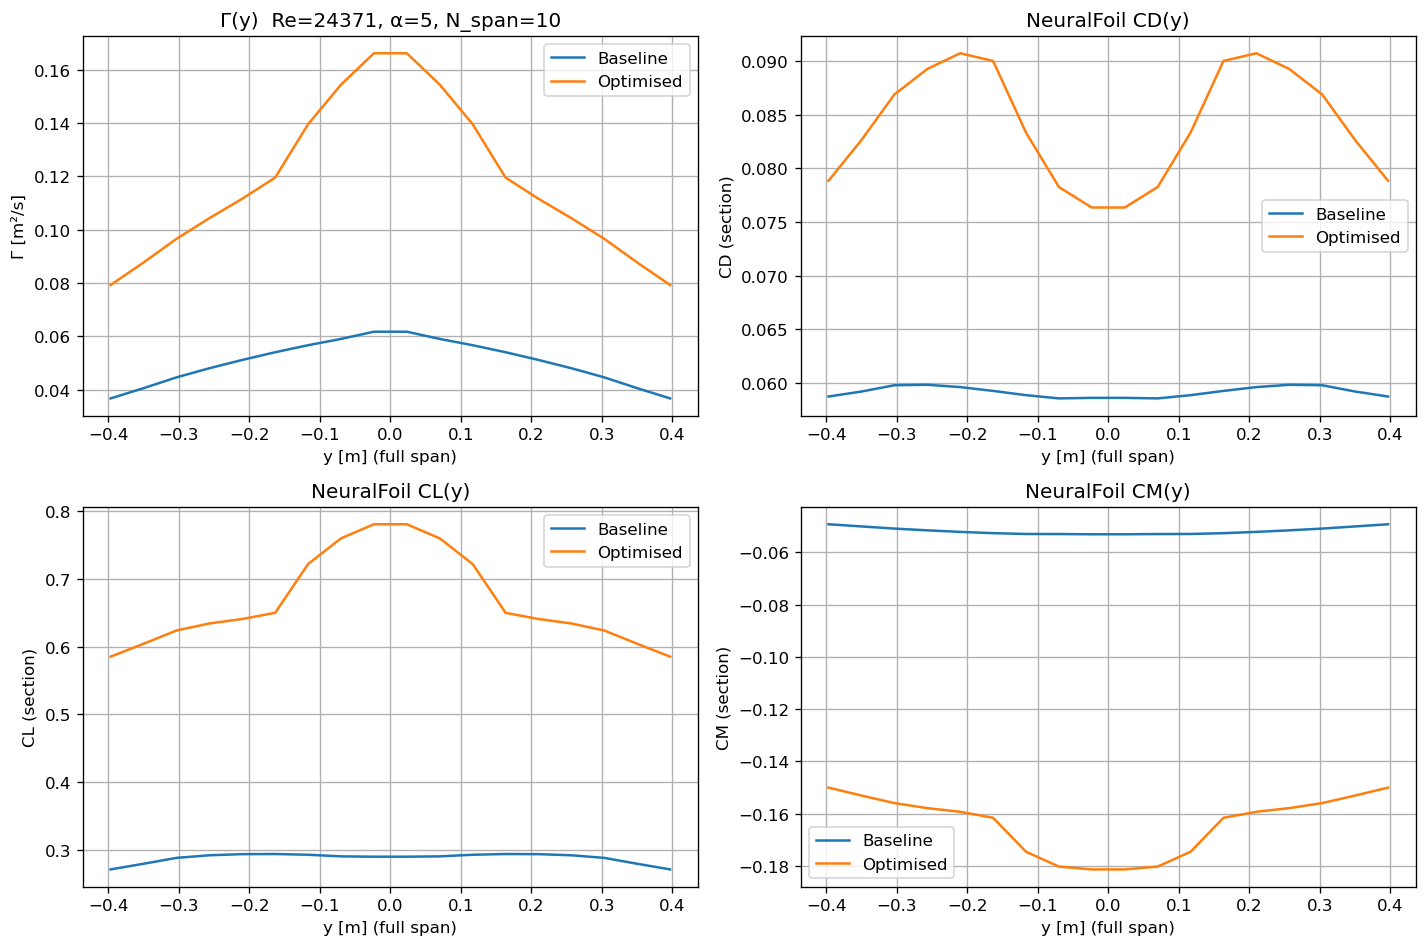

Global coeffs [CL, CD, CM]:
 baseline : [ 0.2888727   0.06313064 -0.05210451]
 optimised: [ 0.67555904  0.10627153 -0.16663106]


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Manual inputs (you set these)
# ---------------------------
RE_REF = float(Re_1d[21])          # must be exactly a grid Re
ALPHA_REF = float(5)    # must be exactly a grid alpha
N_SPAN_STATIONS = 10              # increase/decrease resolution

# rebuild const with requested span resolution using the SAME NF3D rule (endpoints + linspace)
const_b, eta_b = build_const_like_nf3d(cfg_base, n_span_stations=int(N_SPAN_STATIONS))
const_o, eta_o = build_const_like_nf3d(cfg_opt,  n_span_stations=int(N_SPAN_STATIONS))

from IPython.display import display

# single-point solve (now returns spanwise NeuralFoil aero too)
Cb, Gb, aero_b, alphaeff_b, Repan_b, conv_b, it_b, rel_b = solve_llt_forward(
    const_b, eta_b, np.array([ALPHA_REF], np.float32), RE_REF, BASE_ROOT, BASE_TIP
)
Co, Go, aero_o, alphaeff_o, Repan_o, conv_o, it_o, rel_o = solve_llt_forward(
    const_o, eta_o, np.array([ALPHA_REF], np.float32), RE_REF, OPT_ROOT,  OPT_TIP
)

print(f"Baseline:  converged={conv_b}  it={it_b}  rel={rel_b:.2e}")
print(f"Optimised: converged={conv_o}  it={it_o}  rel={rel_o:.2e}")

# full-span y
y_b = const_b.y.detach().cpu().numpy()
y_o = const_o.y.detach().cpu().numpy()

# circulation
Gamma_b = Gb[0]
Gamma_o = Go[0]

# spanwise NeuralFoil outputs at the converged alpha_eff
CL_b = aero_b["CL"][0].detach().cpu().numpy()
CD_b = aero_b["CD"][0].detach().cpu().numpy()
CM_b = aero_b["CM"][0].detach().cpu().numpy()

CL_o = aero_o["CL"][0].detach().cpu().numpy()
CD_o = aero_o["CD"][0].detach().cpu().numpy()
CM_o = aero_o["CM"][0].detach().cpu().numpy()

# sort for clean plots
ib = np.argsort(y_b)
io = np.argsort(y_o)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0][0].plot(y_b[ib], Gamma_b[ib], label="Baseline")
axs[0][0].plot(y_o[io], Gamma_o[io], label="Optimised")
axs[0][0].set_title(f"Γ(y)  Re={RE_REF:.0f}, α={ALPHA_REF:.6g}, N_span={N_SPAN_STATIONS}")
axs[0][0].set_xlabel("y [m] (full span)"); axs[0][0].set_ylabel("Γ [m²/s]")
axs[0][0].grid(True); axs[0][0].legend()

axs[1][0].plot(y_b[ib], CL_b[ib], label="Baseline")
axs[1][0].plot(y_o[io], CL_o[io], label="Optimised")
axs[1][0].set_title("NeuralFoil CL(y)")
axs[1][0].set_xlabel("y [m] (full span)"); axs[1][0].set_ylabel("CL (section)")
axs[1][0].grid(True); axs[1][0].legend()

axs[0][1].plot(y_b[ib], CD_b[ib], label="Baseline")
axs[0][1].plot(y_o[io], CD_o[io], label="Optimised")
axs[0][1].set_title("NeuralFoil CD(y)")
axs[0][1].set_xlabel("y [m] (full span)"); axs[0][1].set_ylabel("CD (section)")
axs[0][1].grid(True); axs[0][1].legend()

axs[1][1].plot(y_b[ib], CM_b[ib], label="Baseline")
axs[1][1].plot(y_o[io], CM_o[io], label="Optimised")
axs[1][1].set_title("NeuralFoil CM(y)")
axs[1][1].set_xlabel("y [m] (full span)"); axs[1][1].set_ylabel("CM (section)")
axs[1][1].grid(True); axs[1][1].legend()

plt.tight_layout()
display(fig)
plt.close(fig)

print("Global coeffs [CL, CD, CM]:")
print(" baseline :", Cb[0])
print(" optimised:", Co[0])

In [6]:
Gb

array([[0.3421582 , 0.39298663, 0.4453814 , 0.48800248, 0.52490723,
        0.5575149 , 0.58692193, 0.6148957 , 0.64845884, 0.64845884,
        0.6148957 , 0.58692193, 0.5575149 , 0.52490723, 0.48800248,
        0.4453814 , 0.39298663, 0.3421582 ]], dtype=float32)